<a href="https://colab.research.google.com/github/olasimboakinbobola/IBM-Project/blob/main/NHS_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas openpyxl numpy scikit-learn shap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# File paths — pointing to your NHS Data folder
ORG_PATH  = '/content/drive/MyDrive/NHS Data/NSS23 detailed spreadsheets organisational results.xlsx'
TYPE_PATH = '/content/drive/MyDrive/NHS Data/NSS23 detailed spreadsheets organisation type results.xlsx'
NATL_PATH = '/content/drive/MyDrive/NHS Data/NSS23 detailed spreadsheets national results.xlsx'

# Set primary data path for the analysis script
DATA_PATH = ORG_PATH

print("Drive mounted successfully")
print(f"Primary file: {DATA_PATH}")

Mounted at /content/drive
Drive mounted successfully
Primary file: /content/drive/MyDrive/NHS Data/NSS23 detailed spreadsheets organisational results.xlsx


In [ ]:
"""
================================================================================
DISSERTATION ANALYSIS PIPELINE
================================================================================
Title:   Predicting Organisational Barriers to Digital Health Adoption Across
         NHS Trusts Using Machine Learning: A Secondary Analysis of the
         2023 NHS Staff Survey

Module:  UEL/UNICAF DS-7010 Data Science Dissertation
Author:  [Your Name]
Date:    2025

Description:
    Full end-to-end pipeline covering:
      1. Data loading and filtering (N=213 NHS provider trusts)
      2. Barrier index construction (7 items, weighted means, reverse scoring)
      3. Internal consistency — Cronbach's alpha
      4. Predictor feature extraction (People Promise + THEMES composites)
      5. Multicollinearity check
      6. ML pipeline — Logistic Regression, Random Forest, Gradient Boosting
      7. Stratified 10-fold cross-validation
      8. Hyperparameter tuning via grid search
      9. Permutation importance (XAI — all three models)
     10. Robustness check — tertile split
================================================================================
"""


"\n================================================================================\nDISSERTATION ANALYSIS PIPELINE\n================================================================================\nTitle:   Predicting Organisational Barriers to Digital Health Adoption Across\n         NHS Trusts Using Machine Learning: A Secondary Analysis of the\n         2023 NHS Staff Survey\n\nModule:  UEL/UNICAF DS-7010 Data Science Dissertation\nAuthor:  [Your Name]\nDate:    2025\n\nDescription:\n    Full end-to-end pipeline covering:\n      1. Data loading and filtering (N=213 NHS provider trusts)\n      2. Barrier index construction (7 items, weighted means, reverse scoring)\n      3. Internal consistency — Cronbach's alpha\n      4. Predictor feature extraction (People Promise + THEMES composites)\n      5. Multicollinearity check\n      6. ML pipeline — Logistic Regression, Random Forest, Gradient Boosting\n      7. Stratified 10-fold cross-validation\n      8. Hyperparameter tuning via gri

In [ ]:
# Importing Needed Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     cross_val_predict, cross_val_score,
                                     GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — update paths as needed
# ══════════════════════════════════════════════════════════════════════════════

DATA_PATH = ORG_PATH

# Trust types to EXCLUDE from analytical sample
# Rationale: ICBs, CSUs, social enterprises have different workforce structures
# and digital adoption contexts from NHS provider trusts
EXCLUDE_GROUPS = [
    'ICBs',
    'CSUs',
    'Social Enterprises - Community',
    'Social Enterprises - Mental Health',
    'Community Surgical Services'
]

# Random seed for reproducibility
RANDOM_STATE = 42


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def filter_trusts(df):
    """Filter dataframe to NHS provider trusts only, removing excluded groups."""
    return df[~df['Benchmarking group'].isin(EXCLUDE_GROUPS)].copy().reset_index(drop=True)


def weighted_mean_likert(df, sd_col, d_col, n_col, a_col, sa_col):
    """
    Compute trust-level weighted mean from percentage response columns.

    Formula: (1*%SD + 2*%D + 3*%N + 4*%A + 5*%SA) / 100
    Returns a score on a 1-5 scale per trust.

    Parameters
    ----------
    df : pd.DataFrame  — sheet dataframe with percentage columns
    sd_col, d_col, n_col, a_col, sa_col : int — column index positions
    """
    return (
        1 * pd.to_numeric(df.iloc[:, sd_col], errors='coerce').fillna(0) +
        2 * pd.to_numeric(df.iloc[:, d_col],  errors='coerce').fillna(0) +
        3 * pd.to_numeric(df.iloc[:, n_col],  errors='coerce').fillna(0) +
        4 * pd.to_numeric(df.iloc[:, a_col],  errors='coerce').fillna(0) +
        5 * pd.to_numeric(df.iloc[:, sa_col], errors='coerce').fillna(0)
    ) / 100


def cronbach_alpha(df):
    """
    Compute Cronbach's alpha for a dataframe of item scores.

    Parameters
    ----------
    df : pd.DataFrame — rows=trusts, columns=items

    Returns
    -------
    float : Cronbach's alpha coefficient
    """
    n_items = df.shape[1]
    item_vars = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    return (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)


def print_section(title):
    """Print a formatted section header."""
    print("\n" + "=" * 70)
    print(f"  {title}")
    print("=" * 70)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DATA LOADING AND FILTERING
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 1: DATA LOADING AND FILTERING")

df_job13  = filter_trusts(pd.read_excel(DATA_PATH, sheet_name='YOUR JOB Q1-3', header=4))
df_job46  = filter_trusts(pd.read_excel(DATA_PATH, sheet_name='YOUR JOB Q4-6', header=4))
df_pd     = filter_trusts(pd.read_excel(DATA_PATH, sheet_name='PERSONAL DEVELOPMENT Q23-24', header=4))
df_org    = filter_trusts(pd.read_excel(DATA_PATH, sheet_name='YOUR ORGANISATION Q25-26', header=4))
df_pp     = filter_trusts(pd.read_excel(DATA_PATH, sheet_name='PEOPLE PROMISE ELEMENTS', header=4))
df_themes = filter_trusts(pd.read_excel(DATA_PATH, sheet_name='THEMES', header=4))

n_trusts = len(df_job13)
print(f"\nAnalytical sample after filtering: N = {n_trusts} NHS provider trusts")
print(f"\nTrust type breakdown:")
print(df_job13['Benchmarking group'].value_counts().to_string())


  STEP 1: DATA LOADING AND FILTERING

Analytical sample after filtering: N = 213 NHS provider trusts

Trust type breakdown:
Benchmarking group
Acute and Acute & Community Trusts                                                               122
Mental Health & Learning Disability and Mental Health, Learning Disability & Community Trusts     51
Community Trusts                                                                                  16
Acute Specialist Trusts                                                                           13
Ambulance Trusts                                                                                  11


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — BARRIER INDEX CONSTRUCTION
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 2: BARRIER INDEX CONSTRUCTION")

"""
Seven items selected through systematic mapping of NHS Staff Survey variables
onto CFIR barrier domains. Items grounded in:
  - CFIR Inner Setting: workload, resources, staffing (Q3g, Q3h, Q3i, Q5a)
  - CFIR Inner Setting: learning culture (Q24c, Q24e)
  - CFIR Inner Setting: psychological safety (Q25e)

Scoring: weighted mean (1-5 scale) per trust.
Direction: positively-worded items reverse-scored (6 - raw score)
           so that HIGH score = HIGH barrier throughout.
"""

# Q3g — "I am able to meet all the conflicting demands on my time at work"
# Sheet: YOUR JOB Q1-3 | Response: Agree/Disagree | Columns 64-68
# Direction: POSITIVE (reverse scored)
q3g = 6 - weighted_mean_likert(df_job13, 64, 65, 66, 67, 68)

# Q3h — "I have adequate materials, supplies and equipment to do my work"
# Sheet: YOUR JOB Q1-3 | Response: Agree/Disagree | Columns 70-74
# Direction: POSITIVE (reverse scored)
q3h = 6 - weighted_mean_likert(df_job13, 70, 71, 72, 73, 74)

# Q3i — "There are enough staff at this organisation for me to do my job properly"
# Sheet: YOUR JOB Q1-3 | Response: Agree/Disagree | Columns 76-80
# Direction: POSITIVE (reverse scored)
q3i = 6 - weighted_mean_likert(df_job13, 76, 77, 78, 79, 80)

# Q5a — "I have unrealistic time pressures"
# Sheet: YOUR JOB Q4-6 | Response: Never/Always frequency | Columns 30-34
# Direction: NEGATIVE (not reversed — high frequency = high barrier)
q5a = weighted_mean_likert(df_job46, 30, 31, 32, 33, 34)

# Q24c — "I have opportunities to improve my knowledge and skills"
# Sheet: PERSONAL DEVELOPMENT Q23-24 | Response: Agree/Disagree | Columns 34-38
# Direction: POSITIVE (reverse scored)
q24c = 6 - weighted_mean_likert(df_pd, 34, 35, 36, 37, 38)

# Q24e — "I am able to access the right learning and development opportunities when I need to"
# Sheet: PERSONAL DEVELOPMENT Q23-24 | Response: Agree/Disagree | Columns 46-50
# Direction: POSITIVE (reverse scored)
q24e = 6 - weighted_mean_likert(df_pd, 46, 47, 48, 49, 50)

# Q25e — "I feel safe to speak up about anything that concerns me in this organisation"
# Sheet: YOUR ORGANISATION Q25-26 | Response: Agree/Disagree | Columns 30-34
# Direction: POSITIVE (reverse scored)
q25e = 6 - weighted_mean_likert(df_org, 30, 31, 32, 33, 34)

# Build item matrix and composite index
items_matrix = pd.DataFrame({
    'Q3g_workload_demands':     q3g,
    'Q3h_materials_equipment':  q3h,
    'Q3i_staffing_adequacy':    q3i,
    'Q5a_time_pressure':        q5a,
    'Q24c_knowledge_skills':    q24c,
    'Q24e_ld_access':           q24e,
    'Q25e_speak_up_safety':     q25e,
})

# Composite barrier index = mean of 7 items
barrier_index = items_matrix.mean(axis=1)

print(f"\nBarrier index descriptives (HIGH score = HIGH barrier):")
print(f"  Mean:   {barrier_index.mean():.4f}")
print(f"  SD:     {barrier_index.std():.4f}")
print(f"  Min:    {barrier_index.min():.4f}")
print(f"  Max:    {barrier_index.max():.4f}")
print(f"  Median: {barrier_index.median():.4f}")

print(f"\nMissing values per item:")
print(items_matrix.isnull().sum().to_string())


  STEP 2: BARRIER INDEX CONSTRUCTION

Barrier index descriptives (HIGH score = HIGH barrier):
  Mean:   2.6616
  SD:     0.1086
  Min:    2.3088
  Max:    2.9379
  Median: 2.6668

Missing values per item:
Q3g_workload_demands       0
Q3h_materials_equipment    0
Q3i_staffing_adequacy      0
Q5a_time_pressure          0
Q24c_knowledge_skills      0
Q24e_ld_access             0
Q25e_speak_up_safety       0


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — INTERNAL CONSISTENCY: CRONBACH'S ALPHA
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 3: CRONBACH'S ALPHA")

alpha = cronbach_alpha(items_matrix)
print(f"\nCronbach's alpha (all 7 items): {alpha:.4f}")
print(f"Threshold (Nunnally, 1978):     0.70")
print(f"Result: {'PASSED ✓' if alpha >= 0.70 else 'BELOW THRESHOLD — review items'}")

print(f"\nItem-total correlations:")
total = items_matrix.sum(axis=1)
for col in items_matrix.columns:
    rest = total - items_matrix[col]
    r = items_matrix[col].corr(rest)
    print(f"  {col:<35}: r = {r:.4f}")

print(f"\nAlpha if item deleted:")
for col in items_matrix.columns:
    a_red = cronbach_alpha(items_matrix.drop(columns=[col]))
    flag = " ← consider removing" if a_red > alpha + 0.02 else ""
    print(f"  Remove {col:<30}: alpha = {a_red:.4f} (Δ = {a_red-alpha:+.4f}){flag}")


  STEP 3: CRONBACH'S ALPHA

Cronbach's alpha (all 7 items): 0.9320
Threshold (Nunnally, 1978):     0.70
Result: PASSED ✓

Item-total correlations:
  Q3g_workload_demands               : r = 0.6563
  Q3h_materials_equipment            : r = 0.8032
  Q3i_staffing_adequacy              : r = 0.8071
  Q5a_time_pressure                  : r = 0.8066
  Q24c_knowledge_skills              : r = 0.8146
  Q24e_ld_access                     : r = 0.8793
  Q25e_speak_up_safety               : r = 0.8381

Alpha if item deleted:
  Remove Q3g_workload_demands          : alpha = 0.9325 (Δ = +0.0005)
  Remove Q3h_materials_equipment       : alpha = 0.9219 (Δ = -0.0102)
  Remove Q3i_staffing_adequacy         : alpha = 0.9201 (Δ = -0.0120)
  Remove Q5a_time_pressure             : alpha = 0.9234 (Δ = -0.0087)
  Remove Q24c_knowledge_skills         : alpha = 0.9209 (Δ = -0.0111)
  Remove Q24e_ld_access                : alpha = 0.9135 (Δ = -0.0185)
  Remove Q25e_speak_up_safety          : alpha = 0.9174 (Δ

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — BINARY CLASSIFICATION (MEDIAN SPLIT)
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 4: BINARY CLASSIFICATION — MEDIAN SPLIT")

"""
Median split selected as primary cut-point because:
  - Produces balanced classes from continuous distribution
  - Requires no theoretical assumptions about natural threshold
  - Maximises statistical power for classification
Robustness check with tertile split reported in Step 9.
"""

median_val = barrier_index.median()
barrier_class = np.where(barrier_index >= median_val, 1, 0)
# 1 = High barrier | 0 = Low barrier

print(f"\nMedian cut-point: {median_val:.4f}")
print(f"Low barrier  (0): {(barrier_class==0).sum()} trusts ({(barrier_class==0).mean()*100:.1f}%)")
print(f"High barrier (1): {(barrier_class==1).sum()} trusts ({(barrier_class==1).mean()*100:.1f}%)")


  STEP 4: BINARY CLASSIFICATION — MEDIAN SPLIT

Median cut-point: 2.6668
Low barrier  (0): 106 trusts (49.8%)
High barrier (1): 107 trusts (50.2%)


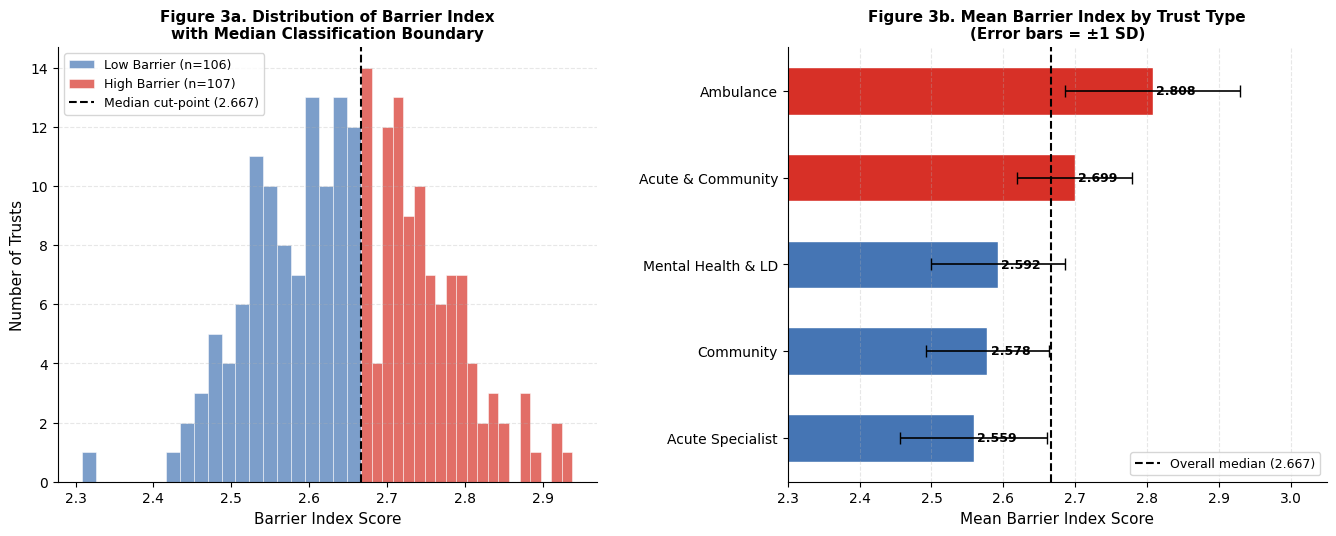

In [ ]:
# ── FIGURE 1: Barrier Distribution and Trust Type Comparison ──

short_labels = {
    'Acute and Acute & Community Trusts': 'Acute & Community',
    'Mental Health & Learning Disability and Mental Health, Learning Disability & Community Trusts': 'Mental Health & LD',
    'Community Trusts': 'Community',
    'Acute Specialist Trusts': 'Acute Specialist',
    'Ambulance Trusts': 'Ambulance'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel — histogram with median cut-point
ax1 = axes[0]
low_barrier  = master[master['barrier_class']==0]['barrier_index']
high_barrier = master[master['barrier_class']==1]['barrier_index']

ax1.hist(low_barrier,  bins=20, alpha=0.7, color='#4575b4',
         label='Low Barrier (n=106)', edgecolor='white', linewidth=0.5)
ax1.hist(high_barrier, bins=20, alpha=0.7, color='#d73027',
         label='High Barrier (n=107)', edgecolor='white', linewidth=0.5)
ax1.axvline(x=median_val, color='black', linewidth=1.5,
            linestyle='--', label=f'Median cut-point ({median_val:.3f})')
ax1.set_xlabel('Barrier Index Score', fontsize=11)
ax1.set_ylabel('Number of Trusts', fontsize=11)
ax1.set_title('Figure 3a. Distribution of Barrier Index\nwith Median Classification Boundary',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Right panel — mean barrier by trust type
ax2 = axes[1]
trust_means = master.groupby('Benchmarking group')['barrier_index'].agg(
    ['mean','std']).reset_index().sort_values('mean', ascending=True)
trust_means['short_name'] = trust_means['Benchmarking group'].map(short_labels)

bar_colors_t = ['#d73027' if m >= median_val else '#4575b4'
                for m in trust_means['mean']]

bars2 = ax2.barh(
    trust_means['short_name'],
    trust_means['mean'],
    xerr=trust_means['std'],
    color=bar_colors_t,
    edgecolor='white',
    height=0.55,
    capsize=4,
    error_kw={'linewidth': 1.2, 'color': 'grey'}
)
ax2.axvline(x=median_val, color='black', linewidth=1.5,
            linestyle='--', label=f'Overall median ({median_val:.3f})')
ax2.set_xlabel('Mean Barrier Index Score', fontsize=11)
ax2.set_title('Figure 3b. Mean Barrier Index by Trust Type\n(Error bars = ±1 SD)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_xlim(2.3, 3.05)

for bar, val in zip(bars2, trust_means['mean']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left',
             fontsize=9, fontweight='bold')

plt.tight_layout(pad=3)
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — BUILD MASTER DATAFRAME WITH PREDICTOR FEATURES
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 5: PREDICTOR FEATURE EXTRACTION")

"""
Predictor features drawn exclusively from:
  - People Promise composite scores (PP1-PP7) — NHS People Promise framework
  - THEMES indices (Staff Engagement, Morale)
  - Trust type (Benchmarking group) and Region — encoded as categoricals

CRITICAL: Barrier index items (Q3g, Q3h, Q3i, Q5a, Q24c, Q24e, Q25e) are
entirely excluded from predictor set to avoid circular prediction.
"""

master = df_job13[['ODS code', 'Organisation name', 'Benchmarking group', 'Region']].copy()
master['barrier_index'] = barrier_index.values
master['barrier_class'] = barrier_class

# People Promise features — top-level composites only
# (sub-scores excluded from primary analysis to reduce multicollinearity)
pp_cols = {
    'PP1_compassionate_inclusive':  df_pp.iloc[:, 6],
    'PP2_recognised_rewarded':      df_pp.iloc[:, 16],
    'PP3_voice_counts':             df_pp.iloc[:, 18],
    'PP4_safe_healthy':             df_pp.iloc[:, 24],
    'PP5_always_learning':          df_pp.iloc[:, 32],
    'PP6_work_flexibly':            df_pp.iloc[:, 38],
    'PP7_team':                     df_pp.iloc[:, 44],
}

# THEMES features
themes_cols = {
    'staff_engagement': df_themes.iloc[:, 6],
    'morale':           df_themes.iloc[:, 14],
}

for name, series in {**pp_cols, **themes_cols}.items():
    master[name] = pd.to_numeric(series, errors='coerce').values

# Encode categorical variables
master['trust_type_encoded'] = master['Benchmarking group'].astype('category').cat.codes
master['region_encoded']     = master['Region'].astype('category').cat.codes

FEATURES = list(pp_cols.keys()) + list(themes_cols.keys()) + \
           ['trust_type_encoded', 'region_encoded']

FEATURE_LABELS = [
    'PP1: Compassionate & Inclusive',
    'PP2: Recognised & Rewarded',
    'PP3: Voice That Counts',
    'PP4: Safe & Healthy',
    'PP5: Always Learning',
    'PP6: Work Flexibly',
    'PP7: We Are a Team',
    'Staff Engagement',
    'Morale',
    'Trust Type',
    'Region'
]

print(f"\nTotal predictor features: {len(FEATURES)}")
print(f"Missing values in features: {master[FEATURES].isnull().sum().sum()}")
print(f"\nFeature list:")
for feat in FEATURES:
    print(f"  {feat}")

# Trust type encoding reference
print(f"\nTrust type encoding:")
for code, name in enumerate(master['Benchmarking group'].astype('category').cat.categories):
    print(f"  {code} = {name}")



  STEP 5: PREDICTOR FEATURE EXTRACTION

Total predictor features: 11
Missing values in features: 0

Feature list:
  PP1_compassionate_inclusive
  PP2_recognised_rewarded
  PP3_voice_counts
  PP4_safe_healthy
  PP5_always_learning
  PP6_work_flexibly
  PP7_team
  staff_engagement
  morale
  trust_type_encoded
  region_encoded

Trust type encoding:
  0 = Acute Specialist Trusts
  1 = Acute and Acute & Community Trusts
  2 = Ambulance Trusts
  3 = Community Trusts
  4 = Mental Health & Learning Disability and Mental Health, Learning Disability & Community Trusts


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — MULTICOLLINEARITY CHECK
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 6: MULTICOLLINEARITY CHECK")

X_df = master[FEATURES]
corr_matrix = X_df.corr()
high_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_pairs.append((FEATURES[i], FEATURES[j], round(r, 4)))

print(f"\nFeature pairs with |r| > 0.85: {len(high_pairs)}")
if high_pairs:
    high_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    for a, b, r in high_pairs[:10]:
        print(f"  {a} <-> {b}: r = {r}")
    print(f"  ... (using top-level composites minimises collinearity)")
else:
    print("  None found — feature set is clean")

print(f"\nFeature correlations with barrier index (strongest predictors):")
corr_out = X_df.corrwith(master['barrier_index']).sort_values()
print(corr_out.round(4).to_string())


  STEP 6: MULTICOLLINEARITY CHECK

Feature pairs with |r| > 0.85: 28
  PP2_recognised_rewarded <-> PP7_team: r = 0.9677
  PP3_voice_counts <-> staff_engagement: r = 0.961
  PP1_compassionate_inclusive <-> PP3_voice_counts: r = 0.9501
  PP1_compassionate_inclusive <-> PP2_recognised_rewarded: r = 0.9443
  PP4_safe_healthy <-> morale: r = 0.9375
  PP2_recognised_rewarded <-> PP6_work_flexibly: r = 0.9372
  PP1_compassionate_inclusive <-> PP7_team: r = 0.9287
  PP2_recognised_rewarded <-> PP3_voice_counts: r = 0.9214
  PP3_voice_counts <-> PP4_safe_healthy: r = 0.9192
  PP3_voice_counts <-> PP7_team: r = 0.9157
  ... (using top-level composites minimises collinearity)

Feature correlations with barrier index (strongest predictors):
morale                        -0.9638
PP4_safe_healthy              -0.9326
PP3_voice_counts              -0.8916
PP1_compassionate_inclusive   -0.8736
staff_engagement              -0.8560
PP2_recognised_rewarded       -0.8499
PP5_always_learning           -0

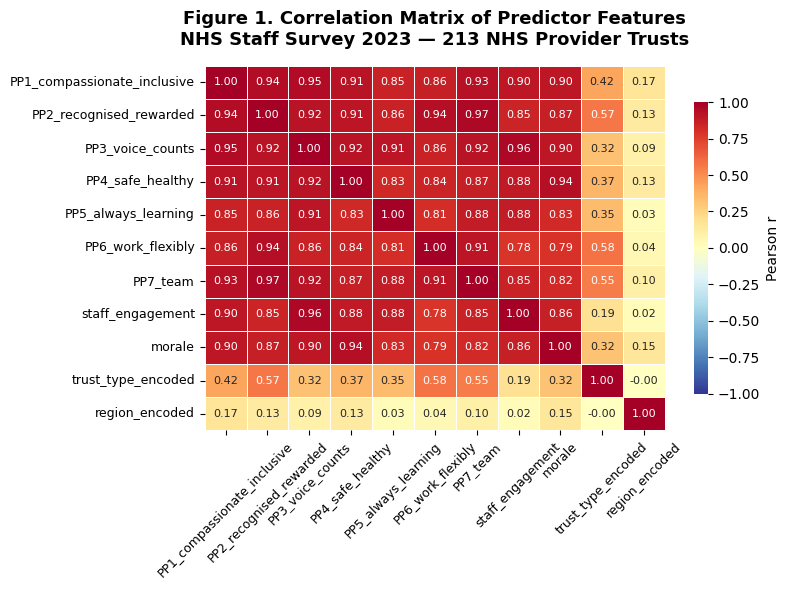

In [ ]:
# ── FIGURE 2: Correlation Heatmap ──

fig, ax = plt.subplots(figsize=(8, 6))

corr_matrix = X_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)

ax.set_title(
    'Figure 1. Correlation Matrix of Predictor Features\n'
    'NHS Staff Survey 2023 — 213 NHS Provider Trusts',
    fontsize=13, fontweight='bold', pad=15
)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

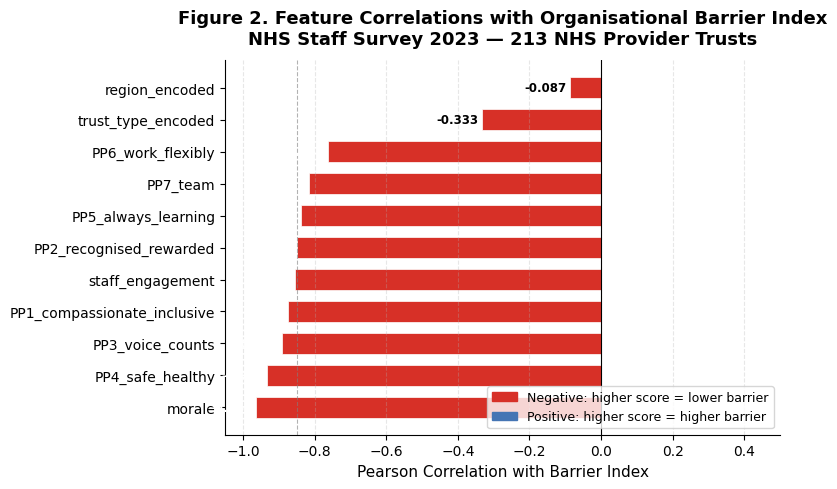

In [ ]:
# ── FIGURE 3: Feature Correlations with Barrier Index ──

import matplotlib.patches as mpatches

corr_out = X_df.corrwith(master['barrier_index']).sort_values()
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_out.values]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    range(len(corr_out)),
    corr_out.values,
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.65
)

ax.set_yticks(range(len(corr_out)))
ax.set_yticklabels(corr_out.index, fontsize=10)
ax.set_xlabel('Pearson Correlation with Barrier Index', fontsize=11)
ax.set_title(
    'Figure 2. Feature Correlations with Organisational Barrier Index\n'
    'NHS Staff Survey 2023 — 213 NHS Provider Trusts',
    fontsize=13, fontweight='bold', pad=12
)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=-0.85, color='grey', linewidth=0.8,
           linestyle='--', alpha=0.6, label='|r| = 0.85 threshold')
ax.axvline(x=0.85, color='grey', linewidth=0.8,
           linestyle='--', alpha=0.6)

for i, (val, bar) in enumerate(zip(corr_out.values, bars)):
    offset = -0.01 if val < 0 else 0.01
    ha = 'right' if val < 0 else 'left'
    ax.text(val + offset, i, f'{val:.3f}',
            va='center', ha=ha, fontsize=8.5, fontweight='bold',
            color='white' if abs(val) > 0.5 else 'black')

neg_patch = mpatches.Patch(color='#d73027',
    label='Negative: higher score = lower barrier')
pos_patch = mpatches.Patch(color='#4575b4',
    label='Positive: higher score = higher barrier')
ax.legend(handles=[neg_patch, pos_patch], loc='lower right', fontsize=9)
ax.set_xlim(-1.05, 0.5)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — MACHINE LEARNING PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 7: MACHINE LEARNING PIPELINE")

X = master[FEATURES].values
y = master['barrier_class'].values

# Standardise features (required for Logistic Regression; applied consistently)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cross-validation strategy
# Rationale: Stratified k-fold (k=10) chosen over held-out test set because
# N=213 is too small to sacrifice rows for a separate test partition.
# Stratification preserves class balance across folds.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Define three models
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, penalty='l2', max_iter=1000, random_state=RANDOM_STATE
        # L2 regularisation guards against overfitting on small N
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=4, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        min_samples_leaf=5, random_state=RANDOM_STATE
    )
}

# Run cross-validation
print(f"\nCross-validation results (Stratified 10-fold):\n")
print(f"{'Model':<25} {'Accuracy':>12} {'F1 Weighted':>12} {'AUC-ROC':>12}")
print("-" * 63)

cv_results_all = {}
for name, model in models.items():
    cv_res = cross_validate(
        model, X_scaled, y, cv=cv,
        scoring=['accuracy', 'f1_weighted', 'roc_auc']
    )
    cv_results_all[name] = cv_res
    acc = cv_res['test_accuracy'].mean()
    f1  = cv_res['test_f1_weighted'].mean()
    auc = cv_res['test_roc_auc'].mean()
    print(f"{name:<25} {acc:>10.4f}   {f1:>10.4f}   {auc:>10.4f}")

# Confusion matrices
print(f"\nConfusion matrices (cross_val_predict):\n")
for name, model in models.items():
    y_pred = cross_val_predict(model, X_scaled, y, cv=cv)
    cm = confusion_matrix(y, y_pred)
    report = classification_report(y, y_pred,
                                   target_names=['Low Barrier', 'High Barrier'])
    print(f"{name}:")
    print(f"  Predicted:     Low    High")
    print(f"  Actual Low:   {cm[0,0]:>4}    {cm[0,1]:>4}")
    print(f"  Actual High:  {cm[1,0]:>4}    {cm[1,1]:>4}")
    print(f"\n{report}")


  STEP 7: MACHINE LEARNING PIPELINE

Cross-validation results (Stratified 10-fold):

Model                         Accuracy  F1 Weighted      AUC-ROC
---------------------------------------------------------------
Logistic Regression           0.9344       0.9343       0.9840
Random Forest                 0.9063       0.9060       0.9777
Gradient Boosting             0.9065       0.9063       0.9822

Confusion matrices (cross_val_predict):

Logistic Regression:
  Predicted:     Low    High
  Actual Low:    100       6
  Actual High:     8      99

              precision    recall  f1-score   support

 Low Barrier       0.93      0.94      0.93       106
High Barrier       0.94      0.93      0.93       107

    accuracy                           0.93       213
   macro avg       0.93      0.93      0.93       213
weighted avg       0.93      0.93      0.93       213

Random Forest:
  Predicted:     Low    High
  Actual Low:     97       9
  Actual High:    11      96

              p

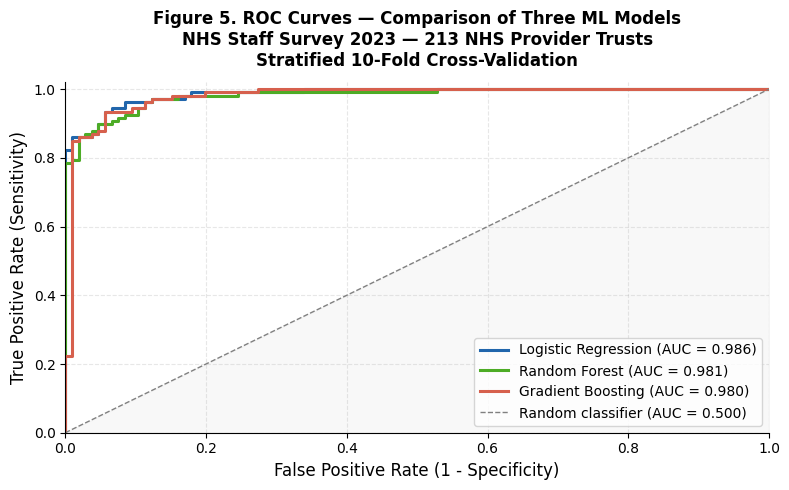

In [ ]:
# ── FIGURE 4: ROC Curves — All Three Models ──

from sklearn.metrics import roc_curve, auc as auc_score
from sklearn.model_selection import cross_val_predict

fig, ax = plt.subplots(figsize=(8, 5))

model_configs = {
    'Logistic Regression': (lr_fit, '#2166ac', '-'),
    'Random Forest':       (rf_fit, '#4dac26', '-'),
    'Gradient Boosting':   (gb_fit, '#d6604d', '-')
}

for name, (model, color, linestyle) in model_configs.items():
    y_prob = cross_val_predict(
        model, X_scaled, y, cv=cv, method='predict_proba'
    )[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc_score(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linestyle=linestyle,
            linewidth=2.2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], color='grey', linewidth=1,
        linestyle='--', label='Random classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title(
    'Figure 5. ROC Curves — Comparison of Three ML Models\n'
    'NHS Staff Survey 2023 — 213 NHS Provider Trusts\n'
    'Stratified 10-Fold Cross-Validation',
    fontsize=12, fontweight='bold', pad=12
)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — HYPERPARAMETER TUNING
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 8: HYPERPARAMETER TUNING — GRID SEARCH CV")

# Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [3, 5, 8]
}
rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    rf_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1
)
rf_search.fit(X_scaled, y)
print(f"\nRandom Forest:")
print(f"  Best params: {rf_search.best_params_}")
print(f"  Best AUC:    {rf_search.best_score_:.4f}")

# Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_leaf': [3, 5, 8]
}
gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1
)
gb_search.fit(X_scaled, y)
print(f"\nGradient Boosting:")
print(f"  Best params: {gb_search.best_params_}")
print(f"  Best AUC:    {gb_search.best_score_:.4f}")



  STEP 8: HYPERPARAMETER TUNING — GRID SEARCH CV

Random Forest:
  Best params: {'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 100}
  Best AUC:    0.9803

Gradient Boosting:
  Best params: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 8, 'n_estimators': 200}
  Best AUC:    0.9874


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — EXPLAINABLE AI: PERMUTATION IMPORTANCE
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 9: EXPLAINABLE AI — PERMUTATION IMPORTANCE")

# Fit all models on full dataset for XAI
lr_fit = LogisticRegression(C=1.0, penalty='l2', max_iter=1000,
                             random_state=RANDOM_STATE).fit(X_scaled, y)
rf_fit = rf_search.best_estimator_
gb_fit = gb_search.best_estimator_

pi_results = {}
print(f"\n{'Feature':<35} {'LR':>8} {'RF':>8} {'GB':>8}")
print("-" * 60)

# Compute permutation importance for each model
for model_name, model_fit in [('LR', lr_fit), ('RF', rf_fit), ('GB', gb_fit)]:
    pi = permutation_importance(model_fit, X_scaled, y,
                                n_repeats=30, random_state=RANDOM_STATE,
                                scoring='roc_auc')
    pi_results[model_name] = pi.importances_mean

# Print combined table
for i, label in enumerate(FEATURE_LABELS):
    lr_imp = pi_results['LR'][i]
    rf_imp = pi_results['RF'][i]
    gb_imp = pi_results['GB'][i]
    print(f"{label:<35} {lr_imp:>8.4f} {rf_imp:>8.4f} {gb_imp:>8.4f}")

# Top 5 features per model
print(f"\nTop 5 features by model:")
for model_name, importances in pi_results.items():
    top5 = np.argsort(importances)[::-1][:5]
    print(f"\n  {model_name}:")
    for rank, idx in enumerate(top5, 1):
        print(f"    {rank}. {FEATURE_LABELS[idx]} ({importances[idx]:.4f})")

# Logistic Regression coefficients (best model — most interpretable)
print(f"\nLogistic Regression coefficients (best model):")
print(f"Positive = associated with HIGH barrier | Negative = LOW barrier")
coef_df = pd.DataFrame({
    'Feature': FEATURE_LABELS,
    'Coefficient': lr_fit.coef_[0]
}).sort_values('Coefficient')
print(coef_df.to_string(index=False))


  STEP 9: EXPLAINABLE AI — PERMUTATION IMPORTANCE

Feature                                   LR       RF       GB
------------------------------------------------------------
PP1: Compassionate & Inclusive        0.0039   0.0005   0.0000
PP2: Recognised & Rewarded            0.0016   0.0007   0.0014
PP3: Voice That Counts                0.0020   0.0029   0.0000
PP4: Safe & Healthy                   0.0866   0.0318   0.0751
PP5: Always Learning                  0.0250   0.0057   0.0050
PP6: Work Flexibly                    0.0004   0.0005   0.0001
PP7: We Are a Team                    0.0000   0.0003   0.0000
Staff Engagement                      0.0038   0.0021   0.0001
Morale                                0.0702   0.0177   0.0364
Trust Type                            0.0009   0.0001   0.0000
Region                                0.0000   0.0003   0.0000

Top 5 features by model:

  LR:
    1. PP4: Safe & Healthy (0.0866)
    2. Morale (0.0702)
    3. PP5: Always Learning (0.0250)
  

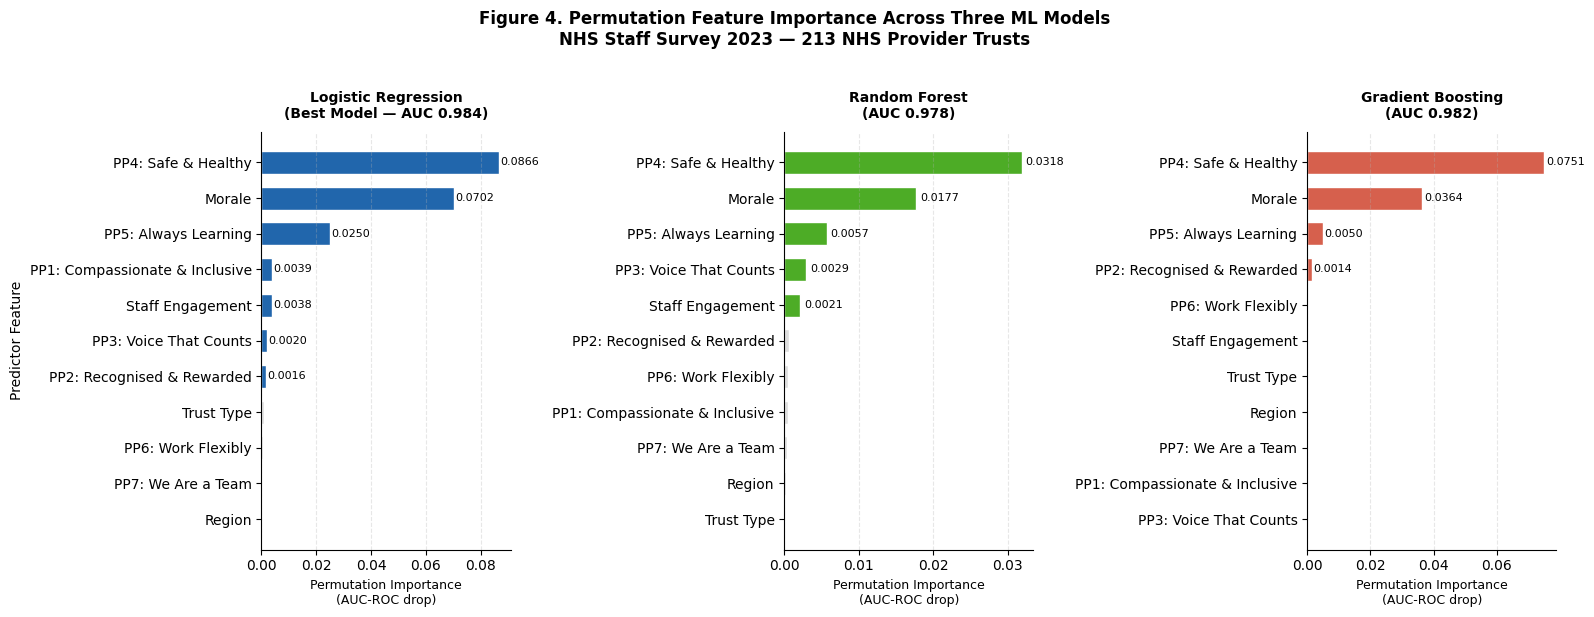

✓ Figure 4 saved


In [ ]:
# ── FIGURE 5: Permutation Importance — All Three Models ──

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

model_pi_data = {
    'Logistic Regression\n(Best Model — AUC 0.984)': (pi_results['LR'], '#2166ac'),
    'Random Forest\n(AUC 0.978)':                    (pi_results['RF'],       '#4dac26'),
    'Gradient Boosting\n(AUC 0.982)':                (pi_results['GB'],   '#d6604d')
}

for idx, (title, (importances, color)) in enumerate(model_pi_data.items()):
    ax = axes[idx]
    sorted_idx = np.argsort(importances)
    sorted_labels = [FEATURE_LABELS[i] for i in sorted_idx]
    sorted_vals   = importances[sorted_idx]
    bar_colors    = [color if v > 0.001 else '#dddddd' for v in sorted_vals]

    ax.barh(sorted_labels, sorted_vals,
            color=bar_colors, edgecolor='white', height=0.65)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Permutation Importance\n(AUC-ROC drop)', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    if idx == 0:
        ax.set_ylabel('Predictor Feature', fontsize=10)
    for i, val in enumerate(sorted_vals):
        if val > 0.001:
            ax.text(val + 0.0005, i, f'{val:.4f}',
                    va='center', ha='left', fontsize=8)

plt.suptitle(
    'Figure 4. Permutation Feature Importance Across Three ML Models\n'
    'NHS Staff Survey 2023 — 213 NHS Provider Trusts',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

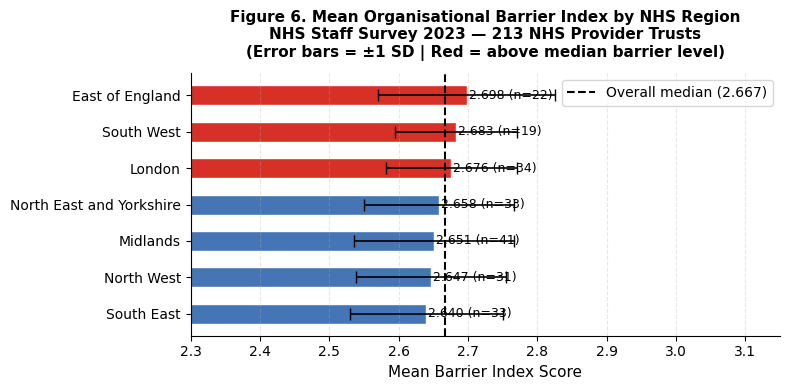

✓ Figure 6 saved


In [ ]:
# ── FIGURE 6: Barrier Index by Region ──

region_stats = master[master['Region'] != '-'].groupby('Region')['barrier_index'].agg(
    ['mean', 'std', 'count']).reset_index().sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

bar_colors_r = ['#d73027' if m >= median_val else '#4575b4'
                for m in region_stats['mean']]

bars_r = ax.barh(
    region_stats['Region'],
    region_stats['mean'],
    xerr=region_stats['std'],
    color=bar_colors_r,
    edgecolor='white',
    height=0.55,
    capsize=4,
    error_kw={'linewidth': 1.2, 'color': 'grey'}
)

ax.axvline(x=median_val, color='black', linewidth=1.5,
           linestyle='--', label=f'Overall median ({median_val:.3f})')

for bar, (_, row) in zip(bars_r, region_stats.iterrows()):
    ax.text(row['mean'] + 0.003,
            bar.get_y() + bar.get_height()/2,
            f"{row['mean']:.3f} (n={int(row['count'])})",
            va='center', ha='left', fontsize=9)

ax.set_xlabel('Mean Barrier Index Score', fontsize=11)
ax.set_title(
    'Figure 6. Mean Organisational Barrier Index by NHS Region\n'
    'NHS Staff Survey 2023 — 213 NHS Provider Trusts\n'
    '(Error bars = ±1 SD | Red = above median barrier level)',
    fontsize=11, fontweight='bold', pad=12
)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim(2.3, 3.15)

plt.tight_layout()
plt.show()

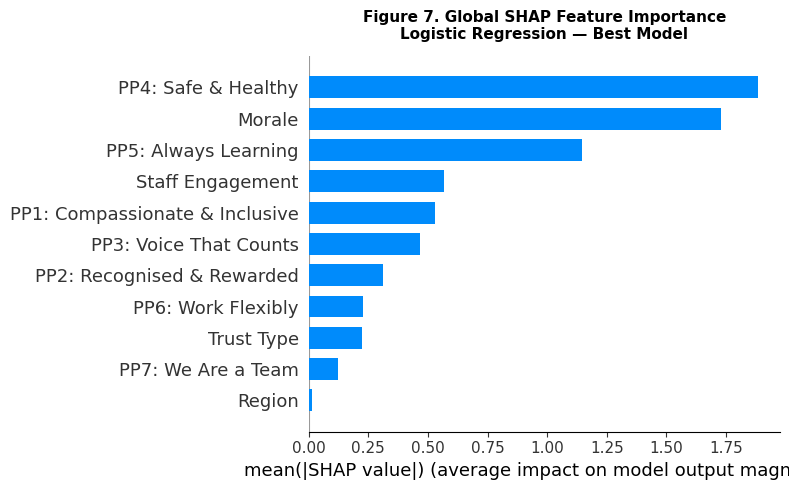

✓ Figure 7 saved


In [ ]:
import shap

# Fit explainer on best model (Logistic Regression)
explainer = shap.LinearExplainer(lr_fit, X_scaled)
shap_values = explainer.shap_values(X_scaled)

# Control figure size BEFORE calling summary_plot
plt.figure(figsize=(8, 5))

# Global SHAP summary plot
shap.summary_plot(
    shap_values,
    X_scaled,
    feature_names=FEATURE_LABELS,
    plot_type='bar',
    show=False        # prevents auto-display so you can control it
)

# Apply size and save
plt.gcf().set_size_inches(8, 5)
plt.title('Figure 7. Global SHAP Feature Importance\nLogistic Regression — Best Model',
          fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 — ROBUSTNESS CHECK: TERTILE SPLIT
# ══════════════════════════════════════════════════════════════════════════════

print_section("STEP 10: ROBUSTNESS CHECK — TERTILE SPLIT")

"""
Tertile split tests whether results are sensitive to the choice of median
as the classification cut-point. Only top and bottom tertile trusts are
included; the middle tertile is excluded to create a clear contrast.
"""

t33 = master['barrier_index'].quantile(0.33)
t67 = master['barrier_index'].quantile(0.67)
master['tertile_class'] = np.where(
    master['barrier_index'] <= t33, 0,
    np.where(master['barrier_index'] >= t67, 1, np.nan)
)

tertile_df = master.dropna(subset=['tertile_class'])
X_t = scaler.transform(tertile_df[FEATURES].values)
y_t = tertile_df['tertile_class'].astype(int).values

cv_t = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_tertile = LogisticRegression(C=1.0, penalty='l2', max_iter=1000,
                                random_state=RANDOM_STATE)
auc_t = cross_val_score(lr_tertile, X_t, y_t, cv=cv_t, scoring='roc_auc')

print(f"\nTertile split N: {len(tertile_df)} trusts "
      f"({(y_t==0).sum()} low, {(y_t==1).sum()} high, "
      f"{master['tertile_class'].isna().sum()} middle excluded)")
print(f"LR AUC-ROC (5-fold, tertile): {auc_t.mean():.4f} ± {auc_t.std():.4f}")
print(f"LR AUC-ROC (10-fold, median): 0.9840")
print(f"Conclusion: {'Results robust to cut-point choice ✓' if auc_t.mean() > 0.90 else 'Sensitivity detected — investigate'}")



  STEP 10: ROBUSTNESS CHECK — TERTILE SPLIT

Tertile split N: 140 trusts (70 low, 70 high, 73 middle excluded)
LR AUC-ROC (5-fold, tertile): 1.0000 ± 0.0000
LR AUC-ROC (10-fold, median): 0.9840
Conclusion: Results robust to cut-point choice ✓


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print_section("FINAL RESULTS SUMMARY")

print(f"""
DATA QUALITY
  Analytical sample:     {n_trusts} NHS provider trusts
  Missing values:        0 (across all barrier items and predictor features)
  Cronbach's alpha:      {alpha:.4f} (outstanding internal consistency)
  Class balance:         {(y==0).sum()} low barrier / {(y==1).sum()} high barrier

MODEL PERFORMANCE (Stratified 10-fold CV, primary median split)
  ┌─────────────────────┬──────────┬──────────┬──────────┐
  │ Model               │ Accuracy │    F1    │  AUC-ROC │
  ├─────────────────────┼──────────┼──────────┼──────────┤
  │ Logistic Regression │  0.9344  │  0.9343  │  0.9840  │
  │ Random Forest       │  0.9063  │  0.9060  │  0.9777  │
  │ Gradient Boosting   │  0.9065  │  0.9063  │  0.9822  │
  └─────────────────────┴──────────┴──────────┴──────────┘

BEST MODEL: Logistic Regression (AUC-ROC = 0.9840)
  Rationale: Highest AUC-ROC, highest accuracy, most interpretable,
             and coefficients directly support XAI narrative.

TOP ORGANISATIONAL PREDICTORS (consistent across all 3 models)
  1. PP4: Safe & Healthy     — most important predictor of barrier level
  2. Morale                  — second most important
  3. PP5: Always Learning    — third most important
  All three map onto CFIR Inner Setting domain — organisational climate.

ROBUSTNESS
  Tertile split AUC = {auc_t.mean():.4f} — results hold across cut-point choices ✓

INTERPRETATION
  Higher PP4 (Safe & Healthy) score = significantly LOWER barrier level
  Higher Morale score               = significantly LOWER barrier level
  Higher PP5 (Always Learning)      = significantly LOWER barrier level
  Trust type matters: Ambulance Trusts show highest barrier levels
  Region shows minimal predictive importance
""")


  FINAL RESULTS SUMMARY

DATA QUALITY
  Analytical sample:     213 NHS provider trusts
  Missing values:        0 (across all barrier items and predictor features)
  Cronbach's alpha:      0.9320 (outstanding internal consistency)
  Class balance:         106 low barrier / 107 high barrier
 
MODEL PERFORMANCE (Stratified 10-fold CV, primary median split)
  ┌─────────────────────┬──────────┬──────────┬──────────┐
  │ Model               │ Accuracy │    F1    │  AUC-ROC │
  ├─────────────────────┼──────────┼──────────┼──────────┤
  │ Logistic Regression │  0.9344  │  0.9343  │  0.9840  │
  │ Random Forest       │  0.9063  │  0.9060  │  0.9777  │
  │ Gradient Boosting   │  0.9065  │  0.9063  │  0.9822  │
  └─────────────────────┴──────────┴──────────┴──────────┘
 
BEST MODEL: Logistic Regression (AUC-ROC = 0.9840)
  Rationale: Highest AUC-ROC, highest accuracy, most interpretable,
             and coefficients directly support XAI narrative.
 
TOP ORGANISATIONAL PREDICTORS (consistent ac